Data_Cleaning (imp for training)

In [ ]:
# @title
import pandas as pd
df = pd.read_csv('/content/tagdata_modified_NOx_0.5.csv')

other_cols_drop = [
    'Water Flow Totalisation',
    'Totalised Fuel Flow',
    'COEFF_A_WR',
    'COEFF_B_WR',
    'COEFF_C_WR',
    'COEFF_D_WR',
    'COEFF_M_WR',
    'Unnamed: 0',
    'Time',
    'Boiler Water Level Set Point',
    'Furnace Draft Set Point',
    'Pressure Set Point',
    'Totalised Steam Flow'
]

control_cols = [
    'FuelRate',
    'Water Flow',
    'Id Fan Vfd Speed Control Signal',
    'Oxygen Percentage'
]

cols_to_drop = other_cols_drop

df = df.drop(columns=cols_to_drop, errors='ignore')

df = df.drop(columns=['Time', 'Unnamed: 0'], errors='ignore')

# Convert everything to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Fill NaNs (important)
df = df.ffill().bfill()

# Convert to float
df = df.astype(float)
df_states_controls= df.drop(control_cols, axis= 'columns')

print("Remaining Columns:")
print(df.columns.tolist())
print(df_states_controls.columns.tolist())
print("✅ Data cleaned")

Remaining Columns:
['Aph Exit Flue Gas Temperature', 'Attemperator Outlet Steam Temperature', 'Boiler Exit Flue Gas Temperature', 'Boiler Exit Steam Temp', 'Boiler Water Level', 'Deaerator Inlet Steam Flow', 'Deaerator Tank Pressure', 'Deaerator Tank Temp.', 'Deaerator Water Level', 'Dearator Main Control Valve %', 'Dearator Steam Control Valve %', 'Economizer Outlet Flue Gas Temp.', 'Economizer Outlet Water Temp.', 'Feed Water Temperature', 'Furnace Draft', 'Furnace Temperature', 'Id Fan Inlet Flue Gas Temp.', 'Id Fan Vfd Speed Control Signal', 'Main Control Valve %', 'Oxygen Percentage', 'SMART LOAD FINAL', 'Stack Temperature', 'Steam Flow Reading', 'Steam Pressure', 'Superheated Steam Temperature', 'Water Flow', 'NOx', 'FuelRate', 'Efficiency']
['Aph Exit Flue Gas Temperature', 'Attemperator Outlet Steam Temperature', 'Boiler Exit Flue Gas Temperature', 'Boiler Exit Steam Temp', 'Boiler Water Level', 'Deaerator Inlet Steam Flow', 'Deaerator Tank Pressure', 'Deaerator Tank Temp.', 'D

Pre-Processing of BoilerWaterLevel and furnacDraft (Too Noisy)

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt


def apply_zero_lag_ema_filter(
    df,
    cols_to_filter=None,
    window_size=10,
    replace_original=True,
    keep_extra_columns=True,
    plot=True
):
    """
    Applies zero-lag EMA filtering to selected columns.

    Zero-lag EMA formula:
        EMA1 = EMA(original)
        EMA2 = EMA(EMA1)
        ZLEMA = 2*EMA1 - EMA2

    Parameters
    ----------
    df : pandas DataFrame
        Original dataframe.

    cols_to_filter : list
        Columns to smooth/filter.

    window_size : int
        EMA span.

    replace_original : bool
        If True, replaces original columns with filtered values.
        If False, keeps original columns unchanged.

    keep_extra_columns : bool
        If True, also creates '<col>_original' and '<col>_filtered' columns.

    plot : bool
        If True, plots original vs filtered values.

    Returns
    -------
    df_filtered : pandas DataFrame
        New dataframe with filtered columns.
    """

    if cols_to_filter is None:
        cols_to_filter = [
            'Furnace Draft',
            'Boiler Water Level'
        ]

    df_filtered = df.copy()

    for col in cols_to_filter:
        if col not in df_filtered.columns:
            raise ValueError(f"Column not found in dataframe: {col}")

        original_values = df_filtered[col].copy()

        # EMA 1
        ema1 = (
            original_values
            .ewm(span=window_size, adjust=False)
            .mean()
        )

        # EMA 2
        ema2 = (
            ema1
            .ewm(span=window_size, adjust=False)
            .mean()
        )

        # Zero-lag EMA
        filtered_values = 2 * ema1 - ema2

        if keep_extra_columns:
            df_filtered[f"{col}_original"] = original_values
            df_filtered[f"{col}_filtered"] = filtered_values

        if replace_original:
            df_filtered[col] = filtered_values

    if plot:
        for col in cols_to_filter:
            plt.figure(figsize=(14, 5))

            if keep_extra_columns:
                plt.plot(
                    df_filtered[f"{col}_original"].values,
                    label=f"Original {col}",
                    alpha=0.7
                )
                plt.plot(
                    df_filtered[f"{col}_filtered"].values,
                    label=f"Filtered {col}",
                    linewidth=2
                )
            else:
                plt.plot(
                    df[col].values,
                    label=f"Original {col}",
                    alpha=0.7
                )
                plt.plot(
                    df_filtered[col].values,
                    label=f"Filtered {col}",
                    linewidth=2
                )

            plt.title(f"{col}: Original vs Zero-Lag EMA Filtered")
            plt.xlabel("Sample index")
            plt.ylabel(col)
            plt.grid(True)
            plt.legend()
            plt.show()

    return df_filtered

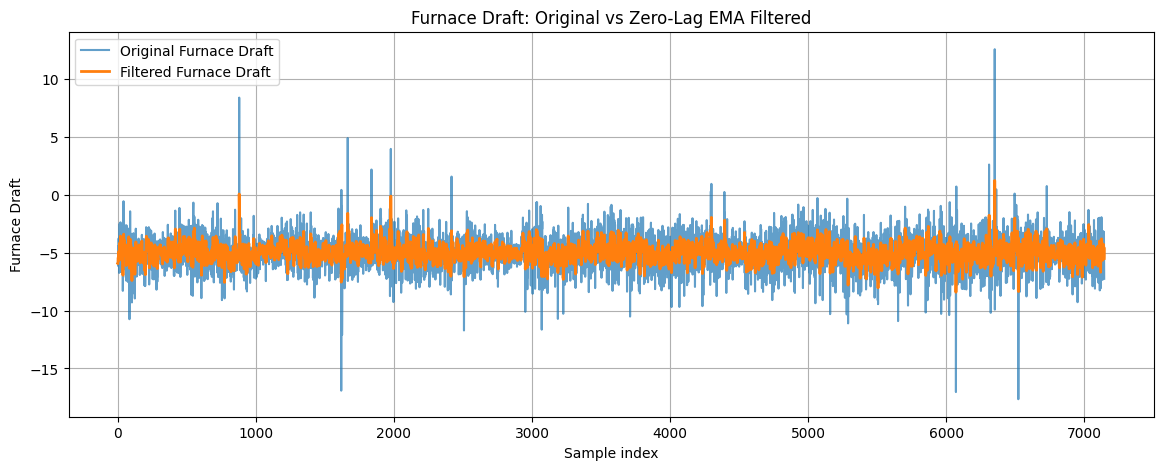

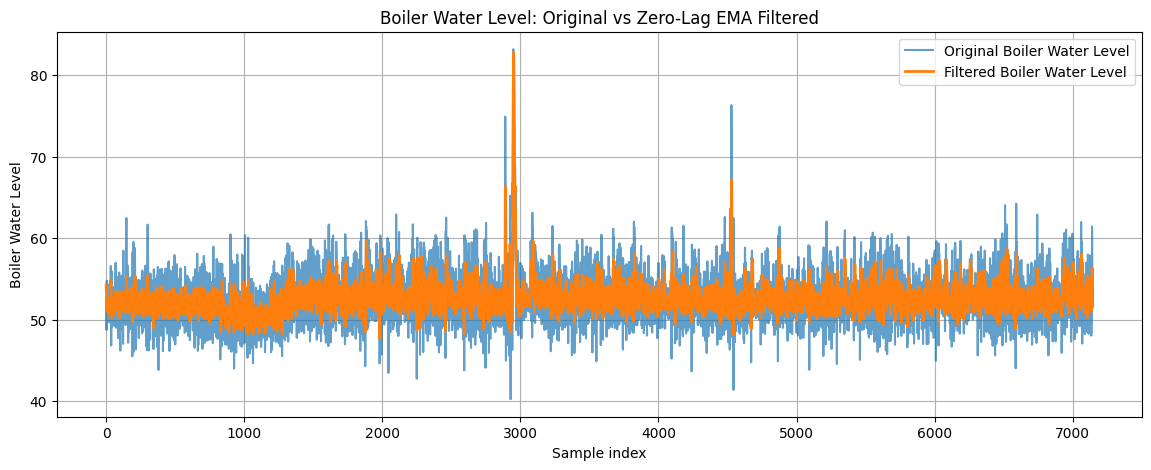

In [ ]:
df= apply_zero_lag_ema_filter(
    df,
    cols_to_filter=None,
    window_size=10,
    replace_original=True,
    keep_extra_columns=False,
    plot=True
)

In [ ]:
df.columns

Index(['Aph Exit Flue Gas Temperature',
       'Attemperator Outlet Steam Temperature',
       'Boiler Exit Flue Gas Temperature', 'Boiler Exit Steam Temp',
       'Boiler Water Level', 'Deaerator Inlet Steam Flow',
       'Deaerator Tank Pressure', 'Deaerator Tank Temp.',
       'Deaerator Water Level', 'Dearator Main Control Valve %',
       'Dearator Steam Control Valve %', 'Economizer Outlet Flue Gas Temp.',
       'Economizer Outlet Water Temp.', 'Feed Water Temperature',
       'Furnace Draft', 'Furnace Temperature', 'Id Fan Inlet Flue Gas Temp.',
       'Id Fan Vfd Speed Control Signal', 'Main Control Valve %',
       'Oxygen Percentage', 'SMART LOAD FINAL', 'Stack Temperature',
       'Steam Flow Reading', 'Steam Pressure', 'Superheated Steam Temperature',
       'Water Flow', 'NOx', 'FuelRate', 'Efficiency'],
      dtype='object')

Residual MLP with GridSearch, The Final One

In [ ]:
# @title
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

control_cols = [
    'FuelRate',
    'Water Flow',
    'Id Fan Vfd Speed Control Signal',
    'Oxygen Percentage'
]

state_cols = [cols for cols in df.columns if cols not in control_cols]

input_cols = state_cols + control_cols

print("Input order:")
print(input_cols)


# ==========================================
# 3. CREATE NEXT + DELTA TARGETS
# ==========================================
df_model = df.copy()

for col in state_cols:
    df_model[f"{col}_next"] = df_model[col].shift(-1)
    df_model[f"{col}_delta"] = df_model[f"{col}_next"] - df_model[col]

df_model = df_model.dropna().reset_index(drop=True)


# ==========================================
# 4. TIME-BASED TRAIN TEST SPLIT
# ==========================================
n = len(df_model)

train_end = int(0.70 * n)
val_end   = int(0.85 * n)

train = df_model.iloc[:train_end]
test  = df_model.iloc[val_end:]


# ==========================================
# 5. METRICS FUNCTION
# ==========================================
def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    rmse_pct = (rmse / (np.mean(np.abs(y_true)) + 1e-6)) * 100
    mae_pct = (mae / (np.mean(np.abs(y_true)) + 1e-6)) * 100

    return rmse, mae, r2, rmse_pct, mae_pct


# ==========================================
# 6. X AND Y
# ==========================================
X_train_raw = train[input_cols].values
X_test_raw  = test[input_cols].values

# true next states
Y_train_next_raw = train[[f"{c}_next" for c in state_cols]].values
Y_test_next_raw  = test[[f"{c}_next" for c in state_cols]].values

# delta targets
Y_train_delta_raw = train[[f"{c}_delta" for c in state_cols]].values
Y_test_delta_raw  = test[[f"{c}_delta" for c in state_cols]].values

# current states for reconstruction
X_train_state_raw = train[state_cols].values
X_test_state_raw  = test[state_cols].values


# ==========================================
# 7. SCALING
# ==========================================
scaler_X = StandardScaler()
scaler_Y_delta = StandardScaler()

X_train = scaler_X.fit_transform(X_train_raw)
X_test  = scaler_X.transform(X_test_raw)

Y_train_delta = scaler_Y_delta.fit_transform(Y_train_delta_raw)


# ==========================================
# 8. PARAM GRID
# ==========================================
param_grid_mlp = {
    "hidden_layer_sizes": [(64, 64), (128, 128), (128, 128, 64)],
    "activation": ["relu", "tanh"],
    "alpha": [1e-4, 1e-3, 1e-2],
    "learning_rate_init": [0.001, 0.0005],
    "max_iter": [1000]
}


# ==========================================
# 9. GRID SEARCH
# ==========================================
mlp_grid_results = []

for params in ParameterGrid(param_grid_mlp):

    model = MLPRegressor(
        **params,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30
    )

    model.fit(X_train, Y_train_delta)

    # predict delta
    Y_pred_delta_scaled = model.predict(X_test)
    Y_pred_delta = scaler_Y_delta.inverse_transform(Y_pred_delta_scaled)

    # reconstruct next state
    Y_pred_next = X_test_state_raw + Y_pred_delta

    target_metrics = {}
    total_r2 = 0

    for j, target in enumerate(state_cols):
        rmse, mae, r2, rmse_p, mae_p = compute_metrics(
            Y_test_next_raw[:, j],
            Y_pred_next[:, j]
        )

        total_r2 += r2

        target_metrics[target] = {
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "RMSE%": rmse_p,
            "MAE%": mae_p
        }

    avg_r2 = total_r2 / len(state_cols)

    mlp_grid_results.append({
        "params": params,
        "avg_R2": avg_r2,
        "metrics": target_metrics
    })


mlp_grid_results = sorted(
    mlp_grid_results,
    key=lambda x: x["avg_R2"],
    reverse=True
)

best_mlp_result = mlp_grid_results[0]
best_mlp_params = best_mlp_result["params"]


print("===== BEST DELTA-MLP PARAMS =====")
print(best_mlp_params)
print("Average R2:", best_mlp_result["avg_R2"])

print("\n===== TARGET-WISE DELTA-MLP METRICS ON x[t+1] =====")
for target, metrics in best_mlp_result["metrics"].items():
    print(target, metrics)


# ==========================================
# 10. TRAIN FINAL DELTA-MLP
# ==========================================
mlp_delta_model_tuned = MLPRegressor(
    **best_mlp_params,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30
)

mlp_delta_model_tuned.fit(X_train, Y_train_delta)

models_mlp_delta = mlp_delta_model_tuned

Input order:
['Aph Exit Flue Gas Temperature', 'Attemperator Outlet Steam Temperature', 'Boiler Exit Flue Gas Temperature', 'Boiler Exit Steam Temp', 'Boiler Water Level', 'Deaerator Inlet Steam Flow', 'Deaerator Tank Pressure', 'Deaerator Tank Temp.', 'Deaerator Water Level', 'Dearator Main Control Valve %', 'Dearator Steam Control Valve %', 'Economizer Outlet Flue Gas Temp.', 'Economizer Outlet Water Temp.', 'Feed Water Temperature', 'Furnace Draft', 'Furnace Temperature', 'Id Fan Inlet Flue Gas Temp.', 'Main Control Valve %', 'SMART LOAD FINAL', 'Stack Temperature', 'Steam Flow Reading', 'Steam Pressure', 'Superheated Steam Temperature', 'NOx', 'Efficiency', 'FuelRate', 'Water Flow', 'Id Fan Vfd Speed Control Signal', 'Oxygen Percentage']
===== BEST DELTA-MLP PARAMS =====
{'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (64, 64), 'learning_rate_init': 0.0005, 'max_iter': 1000}
Average R2: 0.7790642736419399

===== TARGET-WISE DELTA-MLP METRICS ON x[t+1] =====
Aph Exit Flu

Plotting For MLP (delta) and downloading

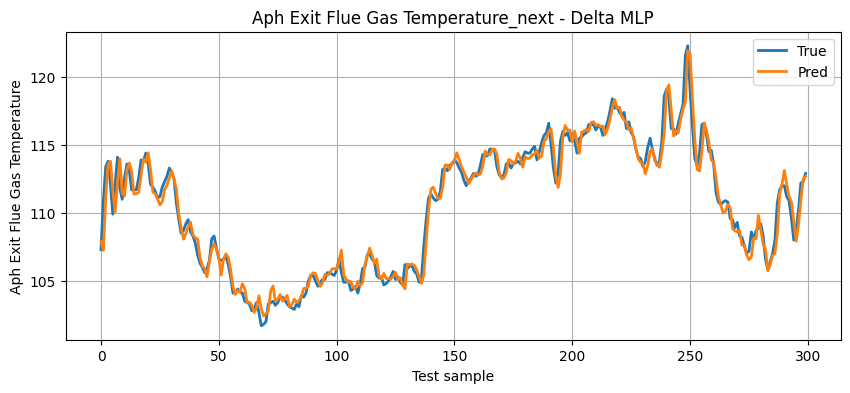

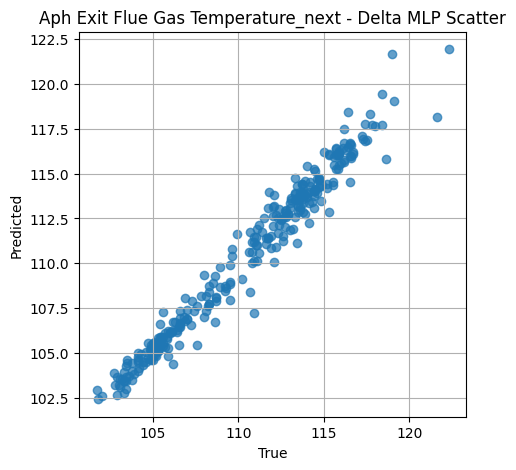

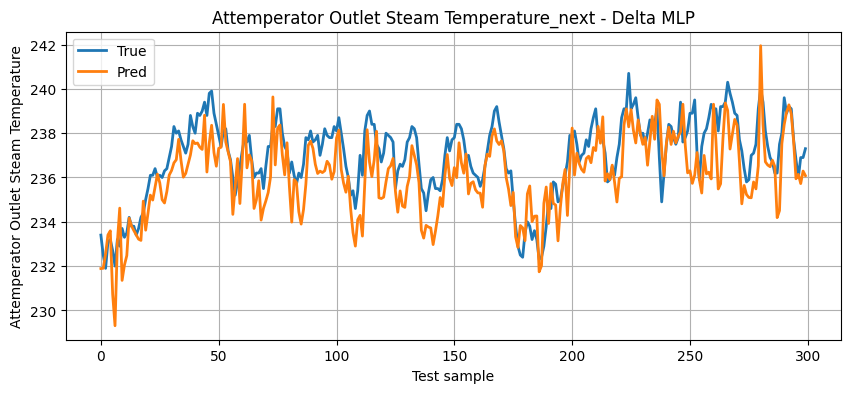

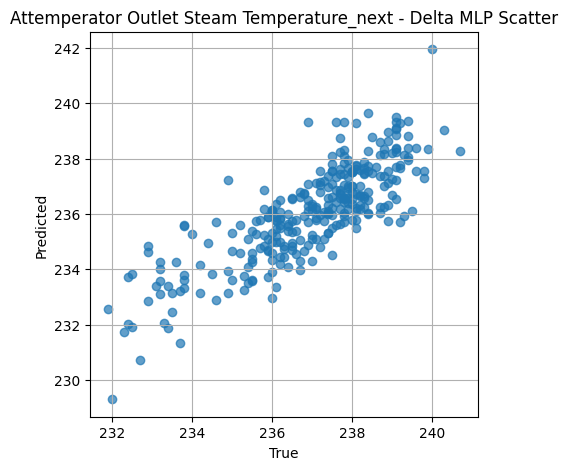

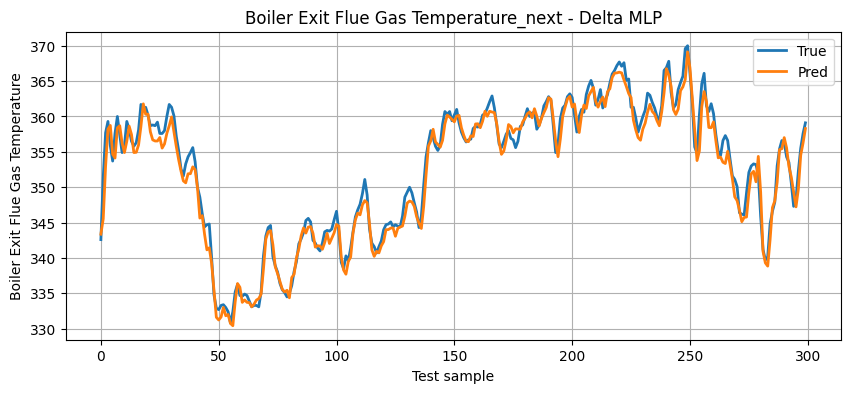

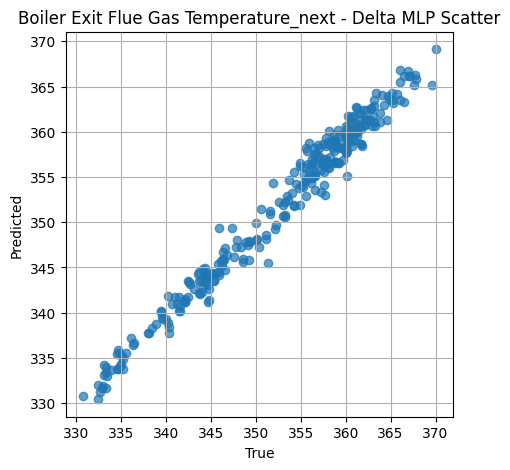

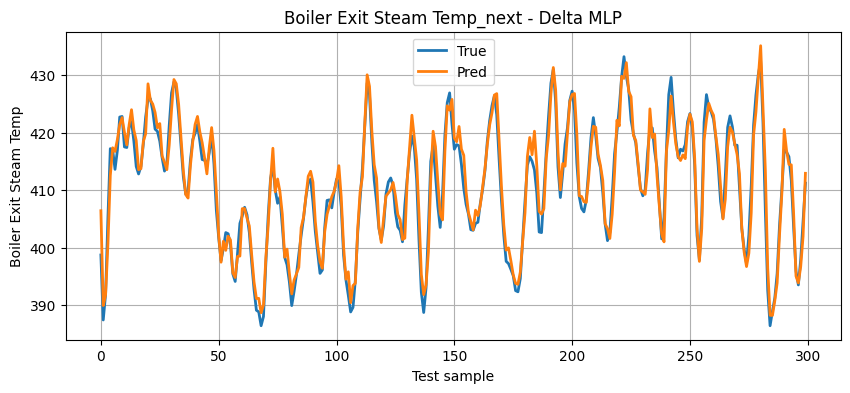

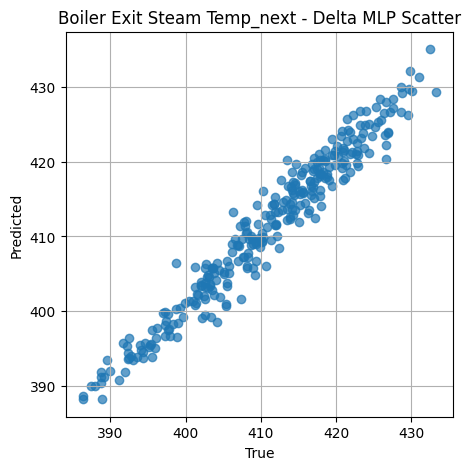

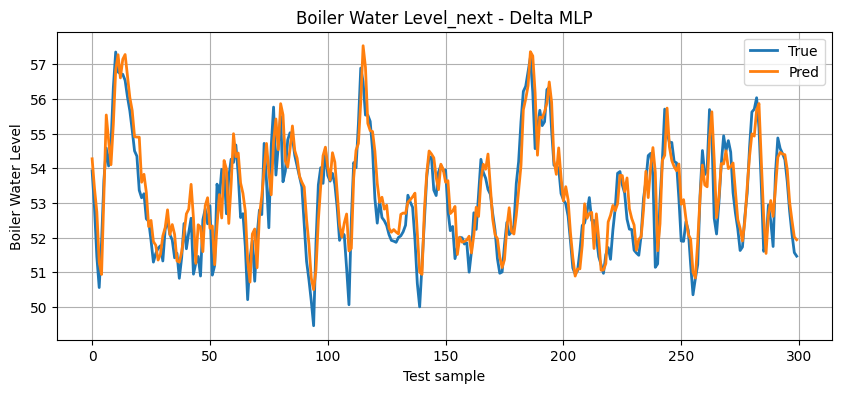

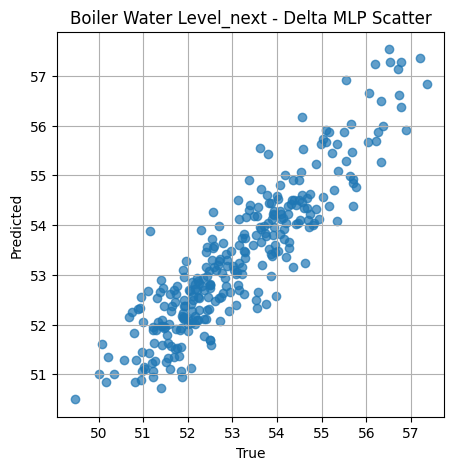

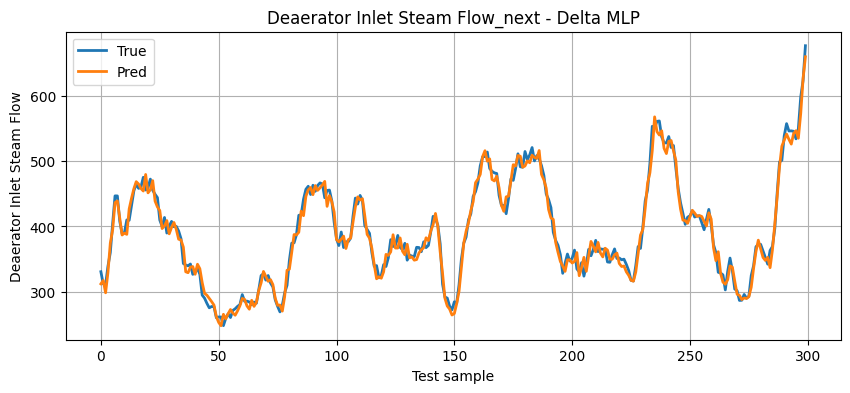

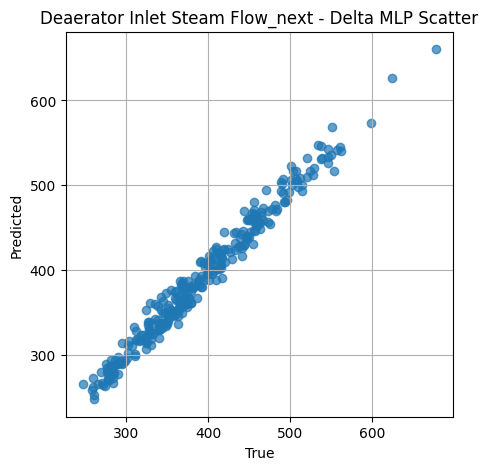

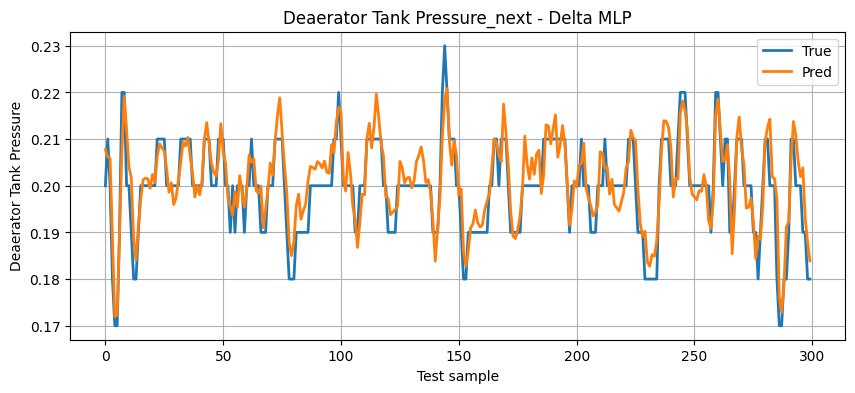

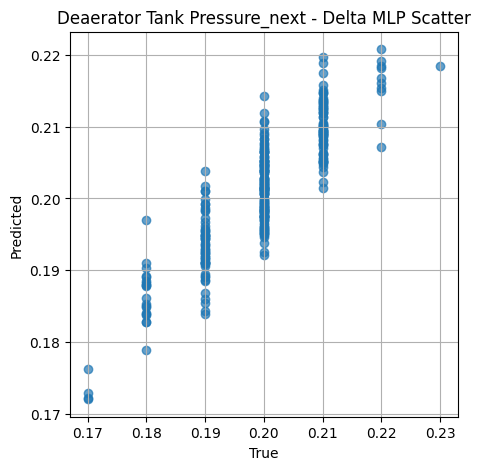

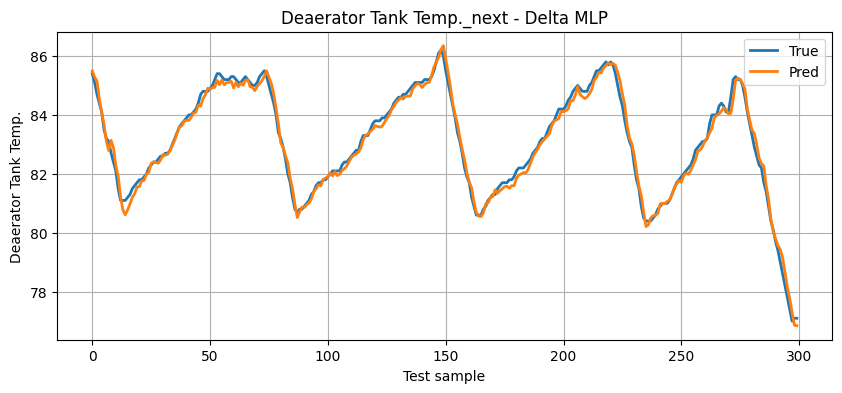

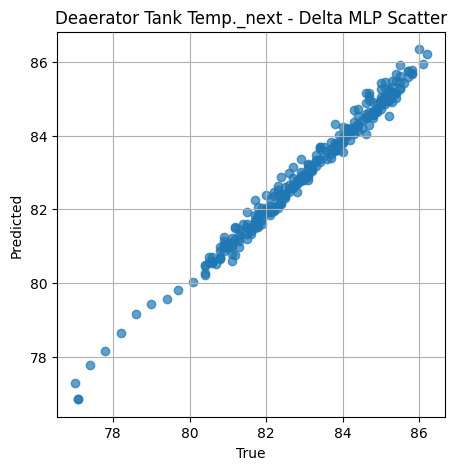

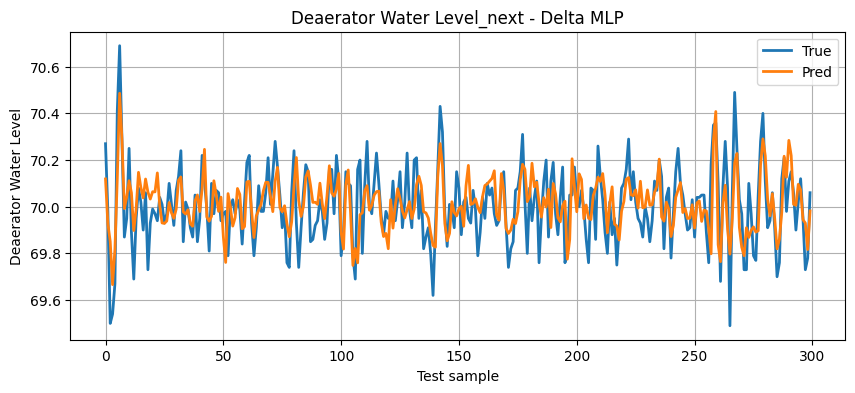

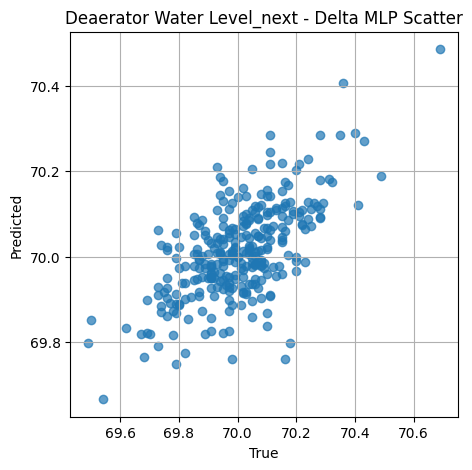

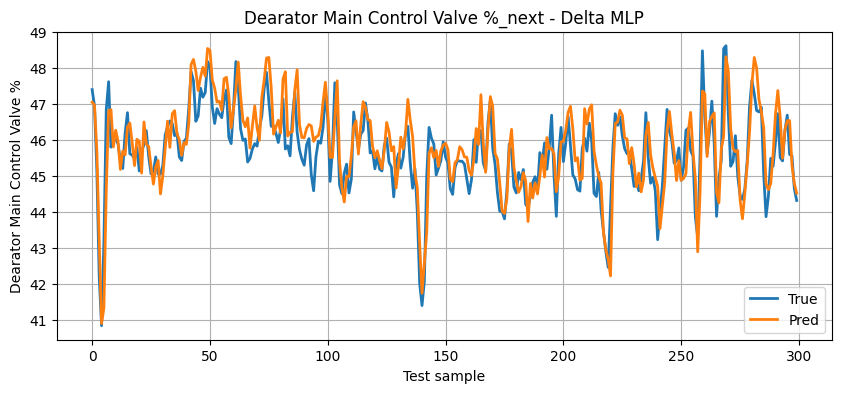

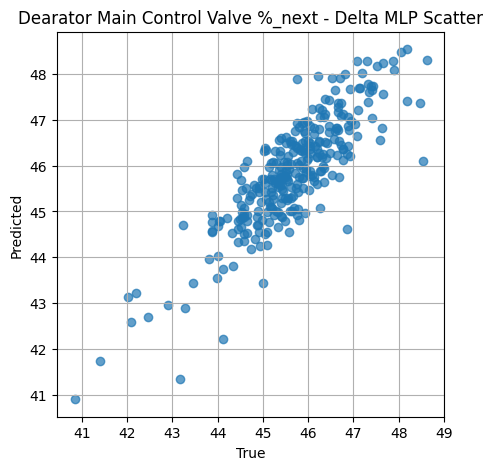

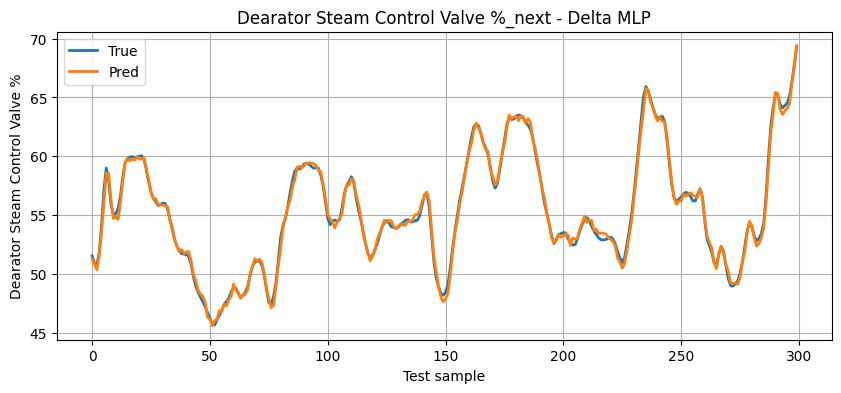

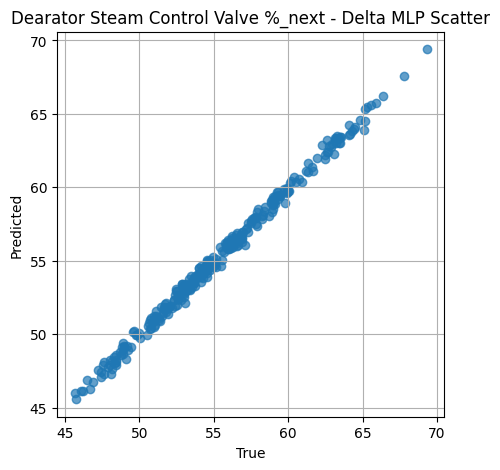

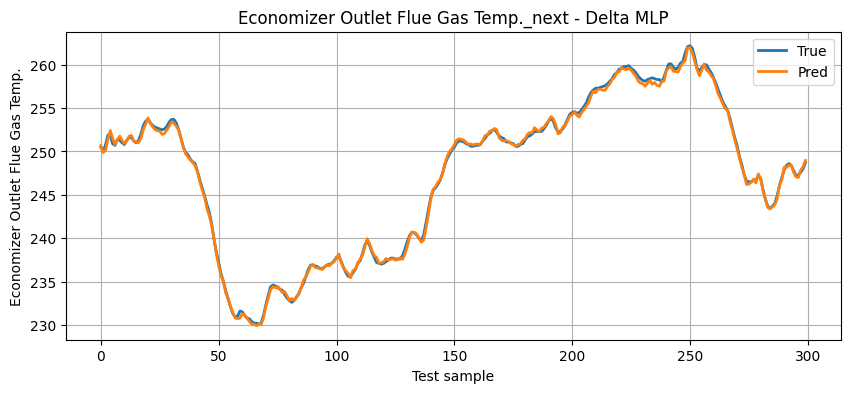

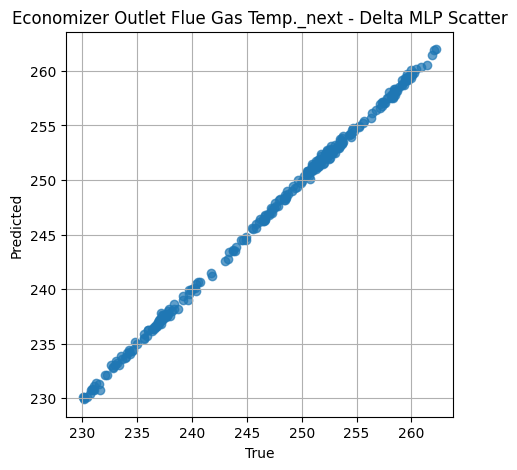

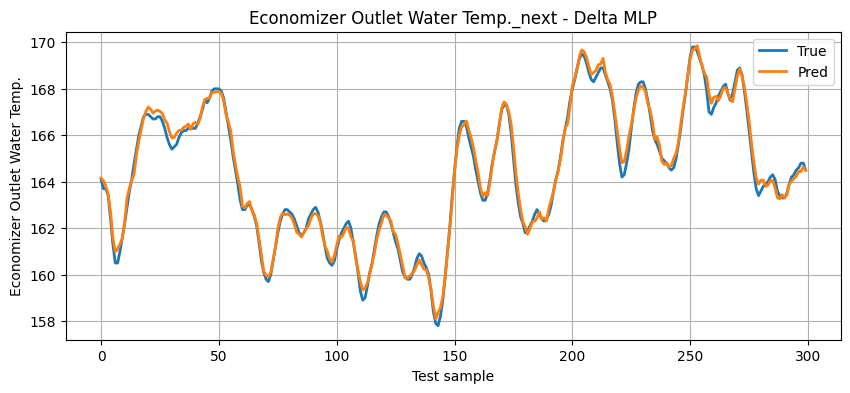

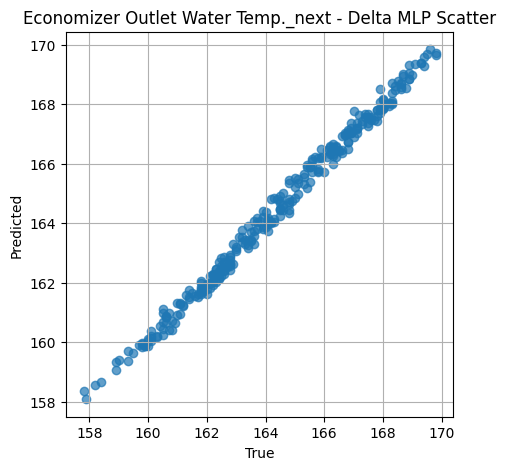

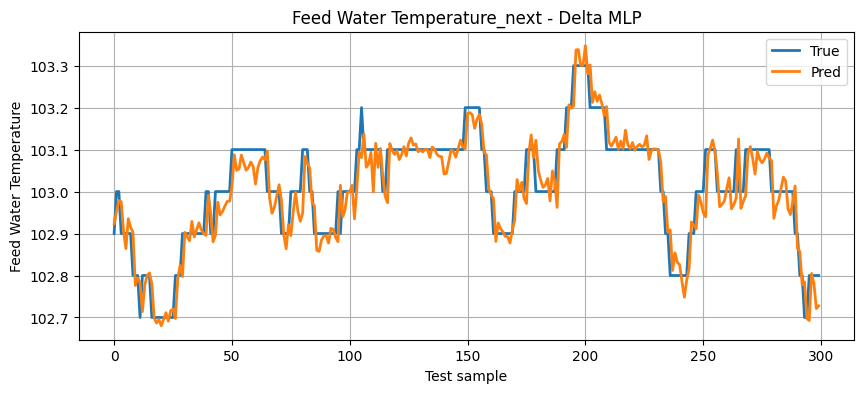

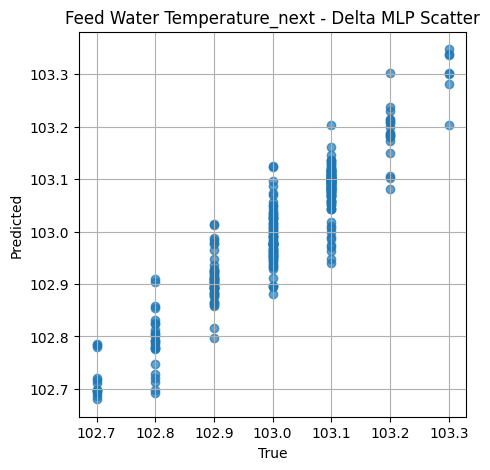

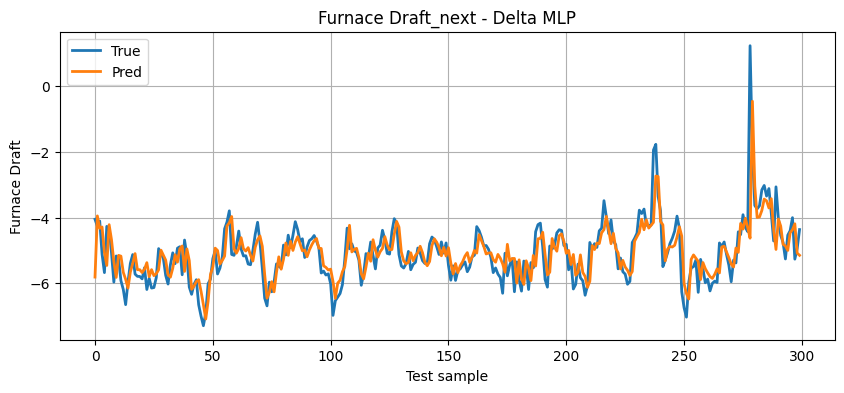

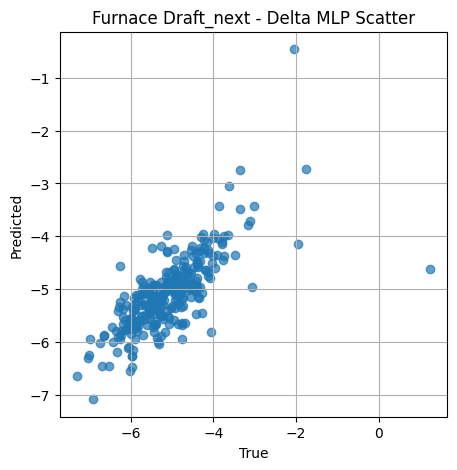

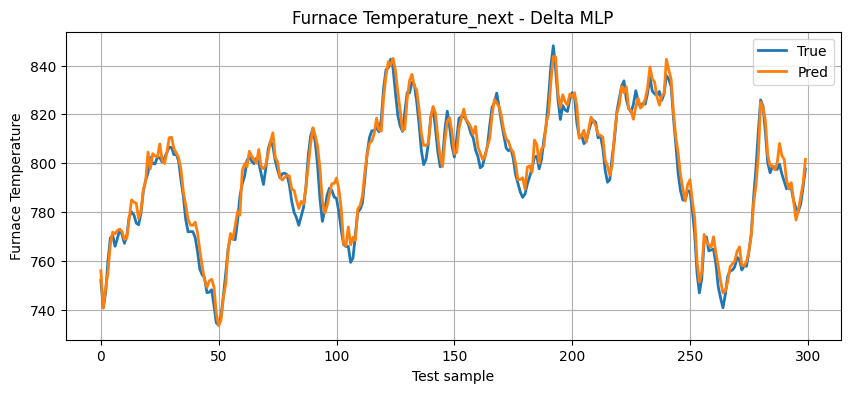

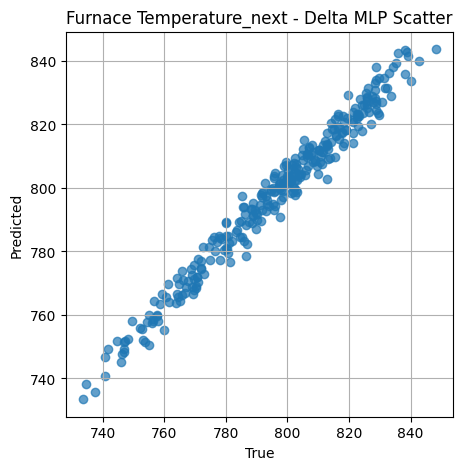

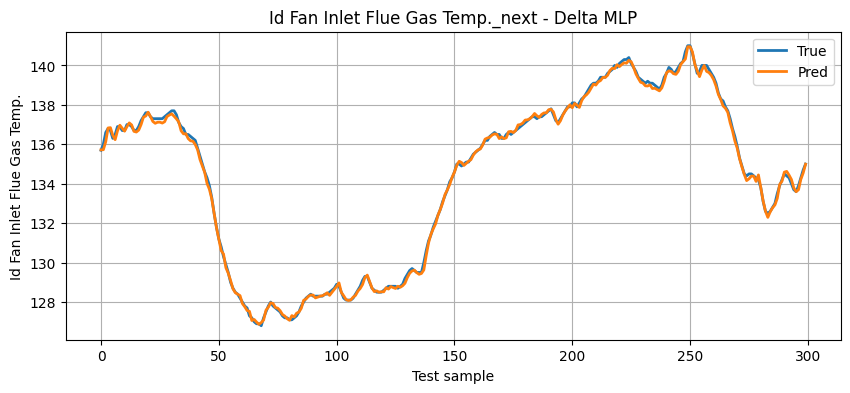

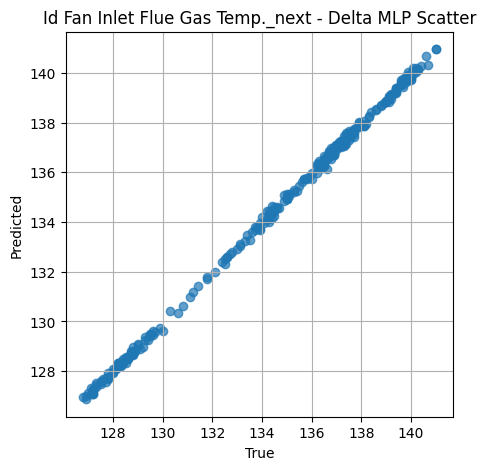

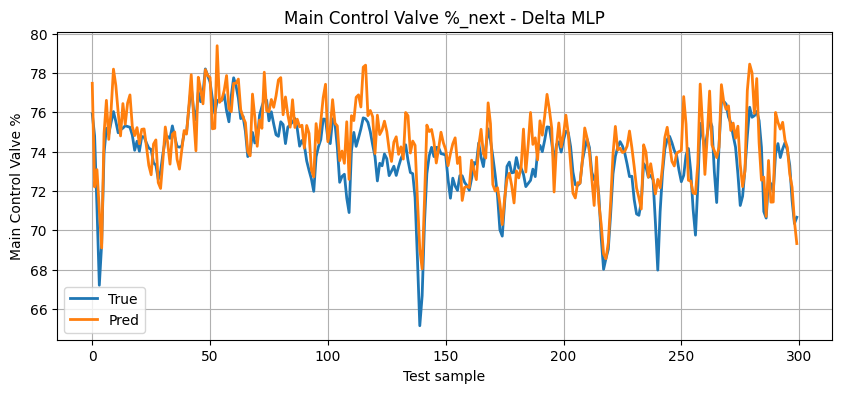

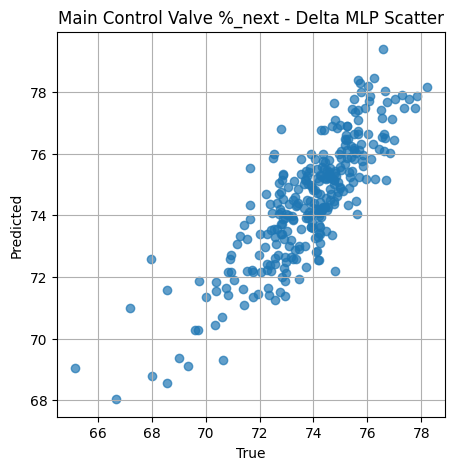

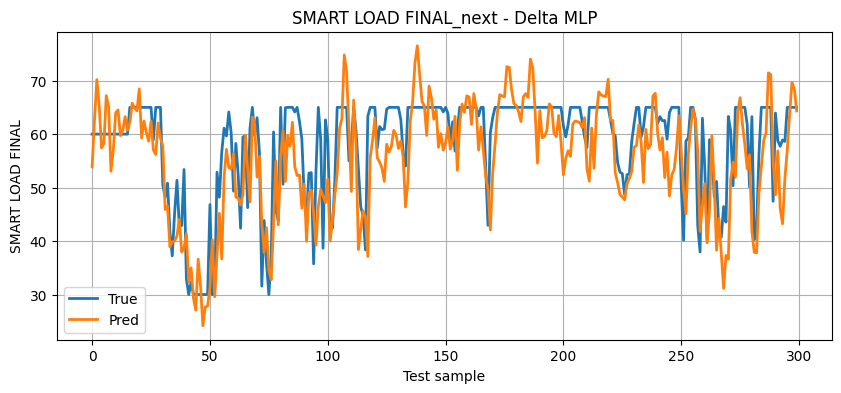

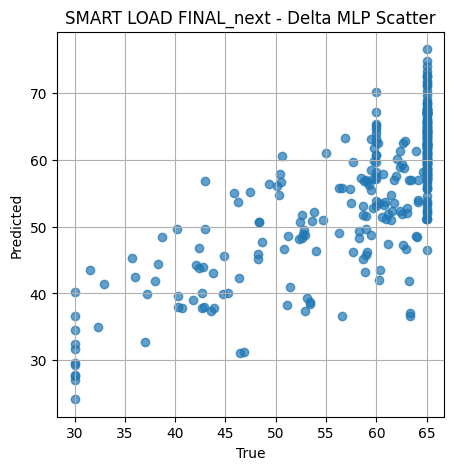

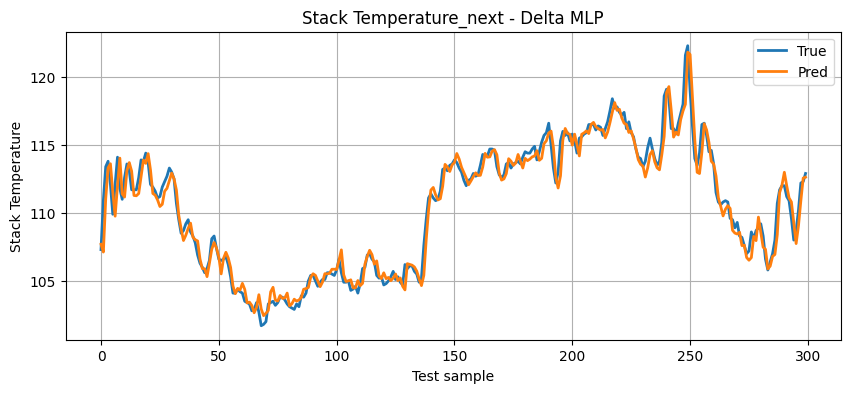

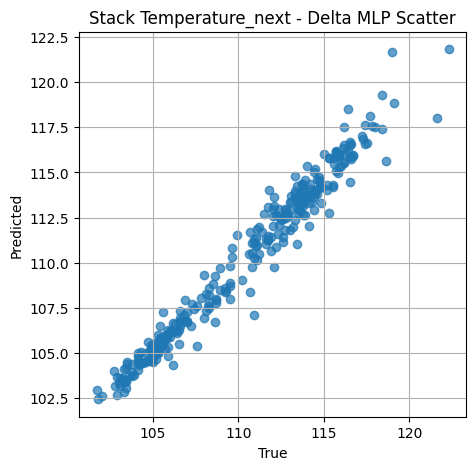

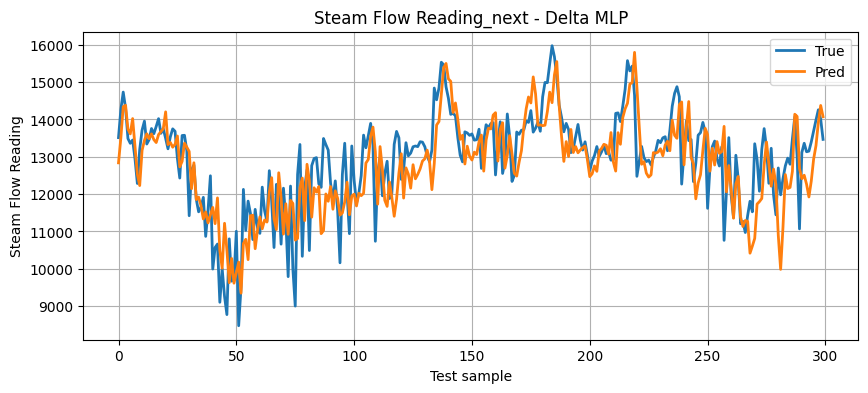

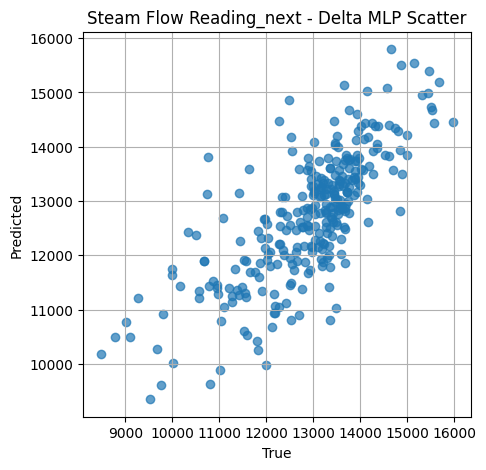

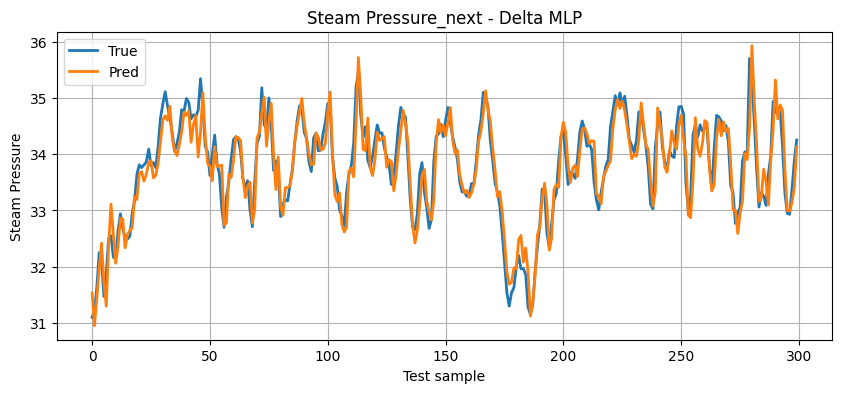

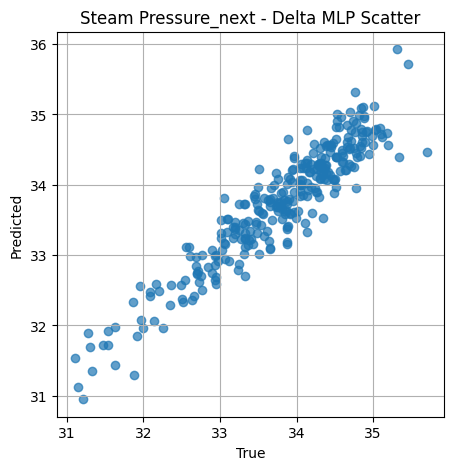

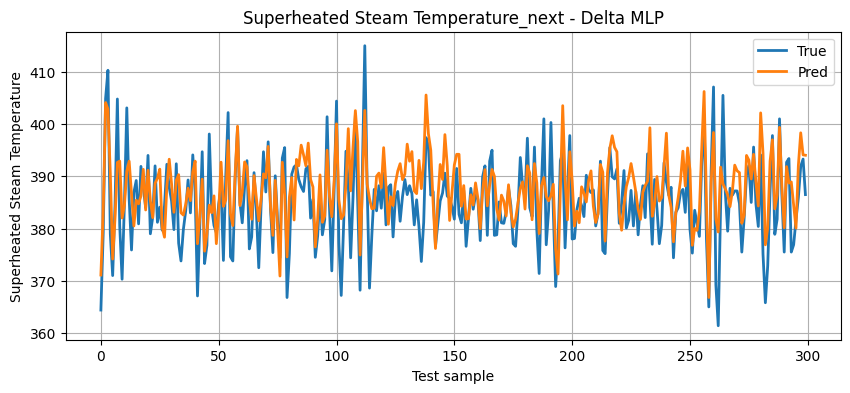

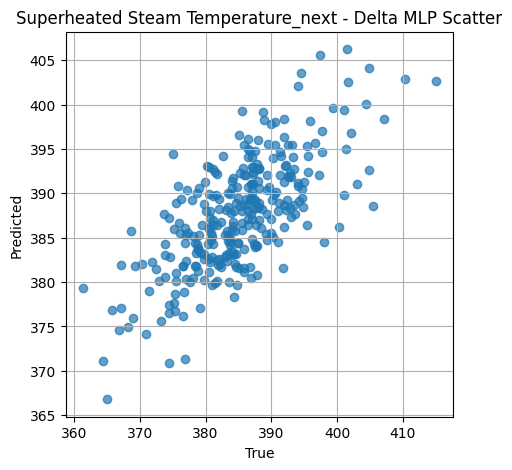

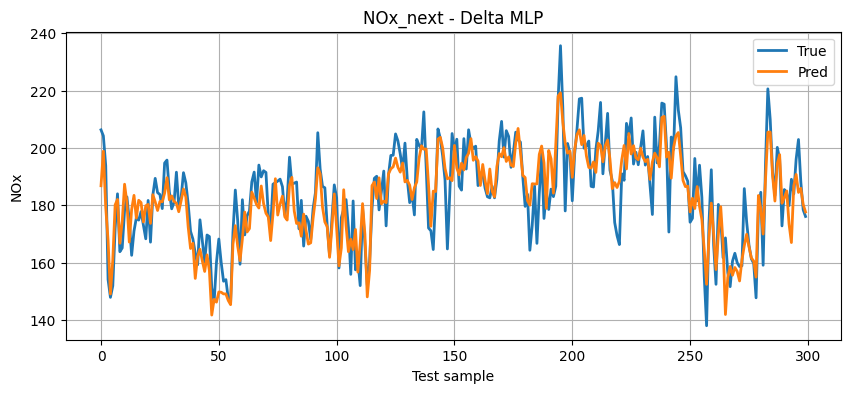

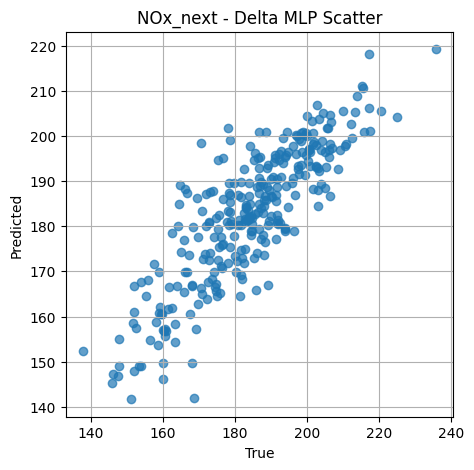

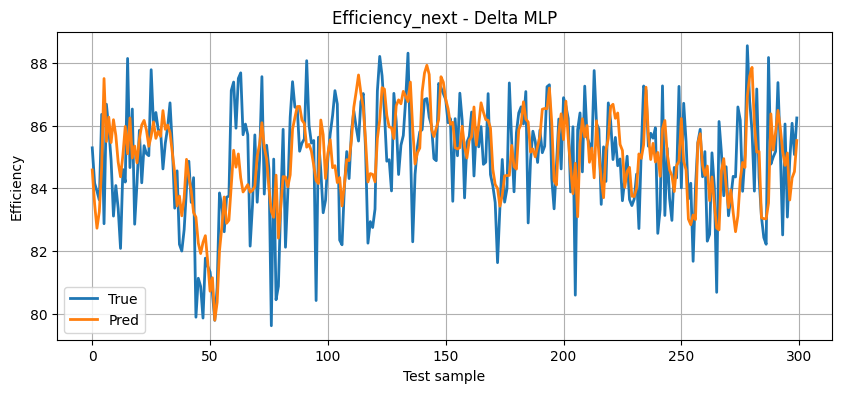

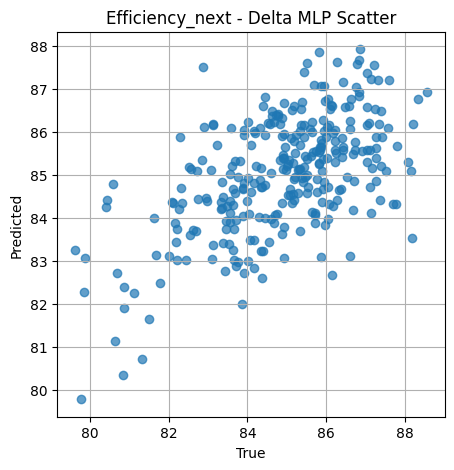

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title
import os
import zipfile
import matplotlib.pyplot as plt
from google.colab import files

# --------------------------------------------------
# 1. Create folder to save plots
# --------------------------------------------------
save_dir = "delta_mlp_plots"
os.makedirs(save_dir, exist_ok=True)

# --------------------------------------------------
# 2. Use tuned delta-MLP model
# --------------------------------------------------
model = models_mlp_delta

# Predict delta in scaled form
Y_pred_delta_scaled = model.predict(X_test)

# Inverse scale delta
Y_pred_delta = scaler_Y_delta.inverse_transform(Y_pred_delta_scaled)

# Reconstruct next state
Y_pred_next = X_test_state_raw + Y_pred_delta

# True next state
Y_test_next = test[[f"{c}_next" for c in state_cols]].values

# --------------------------------------------------
# 3. Generate and save plots
# --------------------------------------------------
for j, target in enumerate(state_cols):

    y_test = Y_test_next[:, j][:300]
    y_pred = Y_pred_next[:, j][:300]

    # Clean filename
    safe_target = target.replace(" ", "_").replace("/", "_").replace("\\", "_")

    # --------------------------------------------------
    # Time series plot
    # --------------------------------------------------
    plt.figure(figsize=(10, 4))
    plt.plot(y_test, label="True", linewidth=2)
    plt.plot(y_pred, label="Pred", linewidth=2)

    plt.title(f"{target}_next - Delta MLP")
    plt.xlabel("Test sample")
    plt.ylabel(target)
    plt.legend()
    plt.grid(True)

    time_series_path = os.path.join(
        save_dir, f"{safe_target}_time_series_delta_mlp.png"
    )

    plt.savefig(time_series_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # --------------------------------------------------
    # Scatter plot
    # --------------------------------------------------
    plt.figure(figsize=(5, 5))
    plt.scatter(y_test, y_pred, alpha=0.7)

    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"{target}_next - Delta MLP Scatter")
    plt.grid(True)

    scatter_path = os.path.join(
        save_dir, f"{safe_target}_scatter_delta_mlp.png"
    )

    plt.savefig(scatter_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

# --------------------------------------------------
# 4. Zip all plots
# --------------------------------------------------
zip_filename = "delta_mlp_plots.zip"

with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, filenames in os.walk(save_dir):
        for filename in filenames:
            file_path = os.path.join(root, filename)
            arcname = os.path.relpath(file_path, save_dir)
            zipf.write(file_path, arcname)

# --------------------------------------------------
# 5. Download zip file
# --------------------------------------------------
files.download(zip_filename)

Predicting next stage

In [ ]:
# @title
def dyn_func_mlp_delta(ctrl_inp, x_prev, model, scaler_X, scaler_Y_delta):

    ctrl_inp = np.array(ctrl_inp, dtype=np.float32)
    x_prev   = np.array(x_prev, dtype=np.float32)

    inp = np.concatenate([x_prev, ctrl_inp]).reshape(1, -1)

    inp_scaled = scaler_X.transform(inp)

    delta_scaled = model.predict(inp_scaled)
    delta = scaler_Y_delta.inverse_transform(delta_scaled).flatten()

    x_next = x_prev + delta

    return x_next.astype(np.float32)

Computing Cost and Get cost over horizon

In [ ]:
# @title
import numpy as np

def get_cost_v2(
    nox, eff, steam_press, boiler_water_level, furnace_draft,

    # setpoints
    steam_press_sp=33,
    boiler_water_level_sp=52,
    furnace_draft_sp=-5,

    # constraints
    nox_constraint=160,

    # weights (Prioritizing efficiency & keeping NOx as a strict barrier)
    eff_weight=100.0,             # High reward for maximizing efficiency
    nox_weight=50.0,           # Severe penalty wall for exceeding NOx limits
    steam_press_weight=1.0,      # Softer squared penalties for tracking
    boiler_water_level_weight=1.30,
    furnace_draft_weight=1.10,

    # ranges (for normalization)
    eff_min=75, eff_max=90,
    nox_min=120, nox_max=260,

    steam_press_min=29.18, steam_press_max=36.51,
    boiler_water_level_min=40.25, boiler_water_level_max=83.15,
    furnace_draft_min=-17.66, furnace_draft_max=12.57
):
    eps = 1e-8

    # --- Efficiency (maximize) ---
    eff_norm = (eff - eff_min) / (eff_max - eff_min + eps)
    cost_eff = -eff_weight * eff_norm

    # --- NOx constraint penalty (Strict Exponential Barrier) ---
    penalty_nox = 0
    if nox_constraint is not None:
        if nox > nox_constraint:
            nox_violation_norm = (nox - nox_constraint) / (nox_max - nox_min + eps)
            penalty_nox = nox_weight * (nox_violation_norm ** 2)

    # --- Tracking penalties (Squared Error / L2 Norm) ---
    # Squaring allows small errors to pass easily but penalizes massive state blowouts exponentially
    steam_err = ((steam_press - steam_press_sp) / (steam_press_max - steam_press_min + eps)) ** 2
    penalty_steam = steam_press_weight * steam_err

    water_err = ((boiler_water_level - boiler_water_level_sp) / (boiler_water_level_max - boiler_water_level_min + eps)) ** 2
    penalty_water = boiler_water_level_weight * water_err

    draft_err = ((furnace_draft - furnace_draft_sp) / (furnace_draft_max - furnace_draft_min + eps)) ** 2
    penalty_draft = furnace_draft_weight * draft_err

    # --- Total cost ---
    total_cost = (
        cost_eff +
        penalty_nox +
        penalty_steam +
        penalty_water +
        penalty_draft
    )

    return total_cost


def compute_cost(flattened_delta_seq,
                 n, k,
                 x_0, u_init,
                 model,
                 scaler_X, scaler_Y_delta,
                 nox_constraint,
                 absolute_bounds):

    # Reshape the 1D optimizer array into a sequence of control MOVEMENT choices (deltas)
    delta_seq = flattened_delta_seq.reshape(k, n)

    x_prev = x_0.copy()
    u_prev = u_init.copy()  # Tracks the rolling baseline position of your controls
    total_cost = 0

    for t in range(k):
        # 1. Add the proposed change to the previous timestep's control position
        ctrl_inp = u_prev + delta_seq[t]

        # 2. Hard clip the resulting values to ensure they stay inside physical equipment limits
        for idx in range(n):
            ctrl_inp[idx] = np.clip(ctrl_inp[idx], absolute_bounds[idx][0], absolute_bounds[idx][1])

        # 3. Predict the state delta and advance the surrogate simulation
        x_next = dyn_func_mlp_delta(ctrl_inp, x_prev, model, scaler_X, scaler_Y_delta)

        # ---- Extract states (Uses the global index variables from your setup) ----
        nox  = x_next[idx_nox]
        eff  = x_next[idx_eff]

        steam_press        = x_next[idx_steam_press]
        boiler_water_level = x_next[idx_water_level]
        furnace_draft      = x_next[idx_furnace_draft]

        # ---- Process the step cost using the revised priorities ----
        total_cost += get_cost_v2(
            nox=nox,
            eff=eff,
            steam_press=steam_press,
            boiler_water_level=boiler_water_level,
            furnace_draft=furnace_draft,
            nox_constraint=nox_constraint
        )

        # 4. Update trajectories to serve as baseline pointers for the next look-ahead step
        x_prev = x_next
        u_prev = ctrl_inp.copy()

    return total_cost

DE

In [ ]:
# @title
from scipy.optimize import differential_evolution

def run_de_mlp_delta(
    x0,
    u_init,
    model,
    scaler_X,
    scaler_Y_delta,
    k,
    delta_bounds,
    absolute_bounds
):
    n_controls = len(control_cols)
    nox_constraint = 140

    # DE now searches inside rate-of-change boundaries across the horizon
    bounds = delta_bounds * k

    def objective(flattened):
        return compute_cost(flattened,
                             n_controls, k,
                             x0, u_init,
                             model,
                             scaler_X, scaler_Y_delta,
                             nox_constraint,
                             absolute_bounds)

    # DEBUG: test objective once before DE
    test_x = np.array([(low + high) / 2 for low, high in bounds], dtype=np.float32)
    print("Testing objective...")
    test_cost = objective(test_x)
    print("Test cost =", test_cost, "type =", type(test_cost))

    result = differential_evolution(
        objective,
        bounds=bounds,
        maxiter=20,      # Raised to give DE room to solve the trajectory
        popsize=10,      # Raised from 5 to prevent optimizer starvation
        tol=1e-2,
        polish=False,
        disp=False,
        workers=1,
        updating="immediate"
    )

    return result.x.reshape(k, n_controls)

Calling (Comparison against df's data)

In [ ]:
# @title
results = []
model = models_mlp_delta

start_idx = 6000
end_idx   = 6050
k = 3

control_cols = ['FuelRate', 'Water Flow', 'Id Fan Vfd Speed Control Signal', 'Oxygen Percentage']
state_cols = [c for c in df.columns if c not in control_cols]

# State Space Indexing
idx_nox = state_cols.index('NOx')
idx_eff = state_cols.index('Efficiency')
idx_steam_press    = state_cols.index('Steam Pressure')
idx_water_level    = state_cols.index('Boiler Water Level')
idx_furnace_draft  = state_cols.index('Furnace Draft')

# Initialize starting positions from historical data
x_real = df.loc[start_idx, state_cols].values.astype(np.float32)
u_real = df.loc[start_idx, control_cols].values.astype(np.float32) # NEW: Track absolute control state

# Hard physical bounds of the equipment
bounds_single_step = [
    (0, 1.4),         # FuelRate Min/Max
    (761, 25000),     # Water Flow Min/Max
    (47, 78),         # Fan Vfd Min/Max
    (4, 10)           # O2 % Min/Max
]

# NEW: Maximum allowable adjustment change (+/-) per single step execution
delta_bounds = [
    (-0.05, 0.05),     # FuelRate maximum change per step
    (-500.0, 500.0),   # Water Flow maximum change per step
    (-2.0, 2.0),       # Id Fan Speed maximum change per step
    (-0.2, 0.2)        # Oxygen Percentage maximum change per step
]

for i in range(start_idx, end_idx):
    print(f"Step {i}")

    try:
        # Compute optimal changes (deltas) starting from where the controls currently are (u_real)
        optimal_delta_seq = run_de_mlp_delta(
                x0=x_real,
                u_init=u_real,
                model=model,
                scaler_X=scaler_X,
                scaler_Y_delta=scaler_Y_delta,
                k=k,
                delta_bounds=delta_bounds,
                absolute_bounds=bounds_single_step
            )

        # Reconstruct the next absolute control move using the first step delta
        best_delta = optimal_delta_seq[0]
        ctrl_mpc = u_real + best_delta

        # Guard-rail clipping to ensure absolute limits are respected
        for idx in range(len(control_cols)):
            ctrl_mpc[idx] = np.clip(ctrl_mpc[idx], bounds_single_step[idx][0], bounds_single_step[idx][1])

        # Step the surrogate simulation forward
        x_next_mpc = dyn_func_mlp_delta(
            ctrl_inp=ctrl_mpc,
            x_prev=x_real,
            model=model,
            scaler_X=scaler_X,
            scaler_Y_delta=scaler_Y_delta
        )

        # Update the simulation states for the next loop iteration
        x_real = x_next_mpc
        u_real = ctrl_mpc # Update our control pointer to the newly established position

        # -------------------------
        # MPC predictions extraction
        # -------------------------
        pred_nox_mpc   = x_next_mpc[idx_nox]
        pred_eff_mpc   = x_next_mpc[idx_eff]
        pred_steam_mpc = x_next_mpc[idx_steam_press]
        pred_water_mpc = x_next_mpc[idx_water_level]
        pred_draft_mpc = x_next_mpc[idx_furnace_draft]

        # -------------------------
        # ACTUAL historical data extraction
        # -------------------------
        actual_nox   = df_states_controls.iloc[i+1]['NOx']
        actual_eff   = df_states_controls.iloc[i+1]['Efficiency']
        actual_steam = df_states_controls.iloc[i+1]['Steam Pressure']
        actual_water = df_states_controls.iloc[i+1]['Boiler Water Level']
        actual_draft = df_states_controls.iloc[i+1]['Furnace Draft']

        FuelRate_Actual   = df.iloc[i+1]['FuelRate']
        Water_Flow_Actual = df.iloc[i+1]['Water Flow']
        Fan_Speed_Actual  = df.iloc[i+1]['Id Fan Vfd Speed Control Signal']
        O2_Actual         = df.iloc[i+1]['Oxygen Percentage']

        # -------------------------
        # STORE RESULTS
        # -------------------------
        results.append({
            'FuelRate_MPC': ctrl_mpc[0],
            'Water Flow_MPC': ctrl_mpc[1],
            'Fan Speed_MPC': ctrl_mpc[2],
            'O2 %_MPC': ctrl_mpc[3],

            'FuelRate_Actual': FuelRate_Actual,
            'Water Flow_Actual': Water_Flow_Actual,
            'Fan Speed_Actual': Fan_Speed_Actual,
            'O2 %_Actual': O2_Actual,

            'Pred NOx MPC': pred_nox_mpc,
            'Pred Efficiency MPC': pred_eff_mpc,
            'Pred Steam Pressure MPC': pred_steam_mpc,
            'Pred Boiler Water Level MPC': pred_water_mpc,
            'Pred Furnace Draft MPC': pred_draft_mpc,

            'Actual NOx': actual_nox,
            'Actual Efficiency': actual_eff,
            'Actual Steam Pressure': actual_steam,
            'Actual Boiler Water Level': actual_water,
            'Actual Furnace Draft': actual_draft
        })

    except Exception as e:
        print(f"❌ Error at index {i}: {e}")
        continue

Step 6000
Testing objective...
Test cost = -159.61154 type = <class 'numpy.float32'>
Step 6001
Testing objective...
Test cost = -172.35666 type = <class 'numpy.float32'>
Step 6002
Testing objective...
Test cost = -179.46756 type = <class 'numpy.float32'>
Step 6003
Testing objective...
Test cost = -186.92146 type = <class 'numpy.float32'>
Step 6004
Testing objective...
Test cost = -213.47675 type = <class 'numpy.float32'>
Step 6005
Testing objective...
Test cost = -231.53857 type = <class 'numpy.float32'>
Step 6006
Testing objective...
Test cost = -239.05493 type = <class 'numpy.float32'>
Step 6007
Testing objective...
Test cost = -231.59534 type = <class 'numpy.float32'>
Step 6008
Testing objective...
Test cost = -218.60199 type = <class 'numpy.float32'>
Step 6009
Testing objective...
Test cost = -204.65898 type = <class 'numpy.float32'>
Step 6010
Testing objective...
Test cost = -185.91098 type = <class 'numpy.float32'>
Step 6011
Testing objective...
Test cost = -164.7944 type = <clas

Plotting States

['FuelRate_MPC', 'Water Flow_MPC', 'Fan Speed_MPC', 'O2 %_MPC', 'FuelRate_Actual', 'Water Flow_Actual', 'Fan Speed_Actual', 'O2 %_Actual', 'Pred NOx MPC', 'Pred Efficiency MPC', 'Pred Steam Pressure MPC', 'Pred Boiler Water Level MPC', 'Pred Furnace Draft MPC', 'Actual NOx', 'Actual Efficiency', 'Actual Steam Pressure', 'Actual Boiler Water Level', 'Actual Furnace Draft']


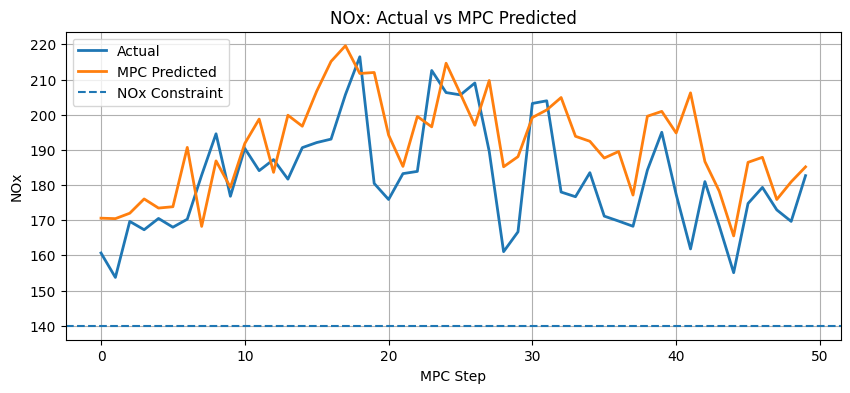

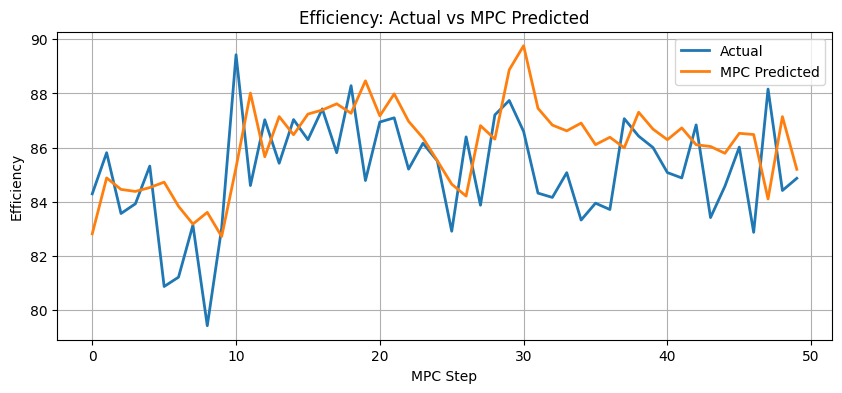

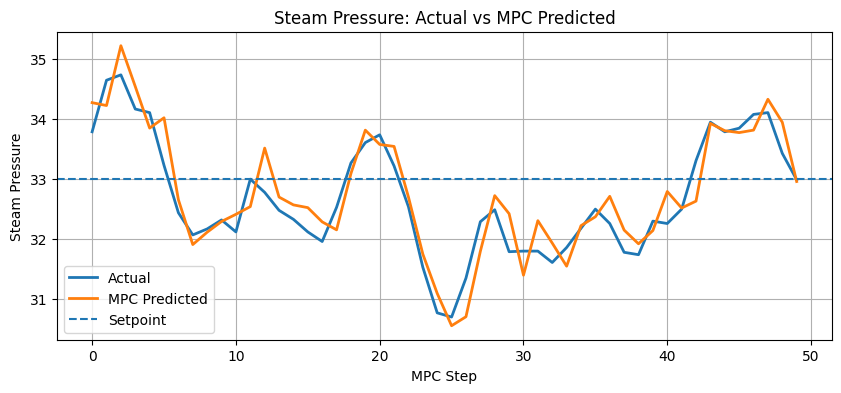

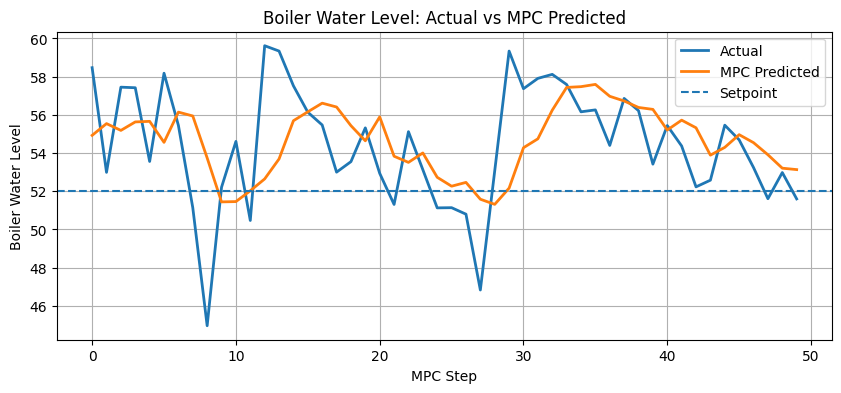

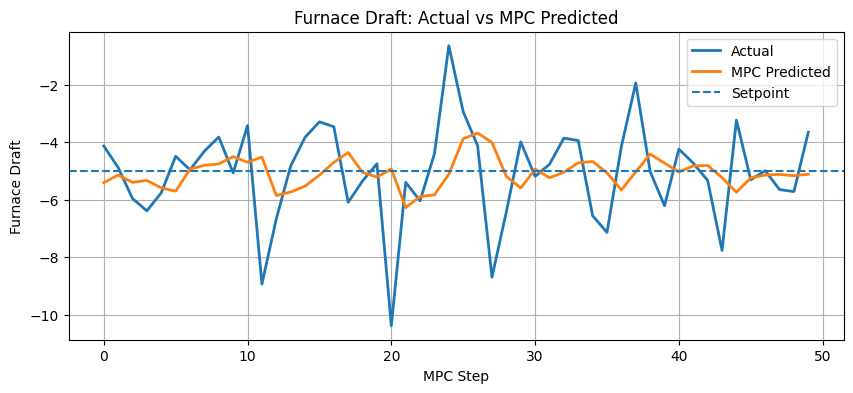

In [ ]:
# @title
import pandas as pd

results_df = pd.DataFrame(results)

print(results_df.columns.tolist())
results_df.head()

import matplotlib.pyplot as plt

# These are the columns actually present in your results_df
state_map = [
    ("NOx", "Actual NOx", "Pred NOx MPC", 140, "NOx Constraint"),
    ("Efficiency", "Actual Efficiency", "Pred Efficiency MPC", None, None),
    ("Steam Pressure", "Actual Steam Pressure", "Pred Steam Pressure MPC", 33, "Setpoint"),
    ("Boiler Water Level", "Actual Boiler Water Level", "Pred Boiler Water Level MPC", 52, "Setpoint"),
    ("Furnace Draft", "Actual Furnace Draft", "Pred Furnace Draft MPC", -5, "Setpoint"),
]

for name, actual_col, mpc_col, ref_value, ref_label in state_map:

    plt.figure(figsize=(10, 4))

    plt.plot(results_df[actual_col].values, label="Actual", linewidth=2)
    plt.plot(results_df[mpc_col].values, label="MPC Predicted", linewidth=2)

    if ref_value is not None:
        plt.axhline(ref_value, linestyle="--", label=ref_label)

    plt.title(f"{name}: Actual vs MPC Predicted")
    plt.xlabel("MPC Step")
    plt.ylabel(name)
    plt.legend()
    plt.grid(True)
    plt.show()

Available columns:
['step', 'Pred NOx', 'Pred Efficiency', 'Pred Steam Pressure', 'Pred Boiler Water Level', 'Pred Furnace Draft', 'Actual NOx', 'Actual Efficiency', 'Actual Steam Pressure', 'Actual Boiler Water Level', 'Actual Furnace Draft', 'FuelRate', 'Water Flow', 'Fan Speed', 'O2 %', 'FuelRate_Actual', 'Water Flow_Actual', 'Fan Speed_Actual', 'O2 %_Actual', 'error']


,step,Pred NOx,Pred Efficiency,Pred Steam Pressure,Pred Boiler Water Level,Pred Furnace Draft,Actual NOx,Actual Efficiency,Actual Steam Pressure,Actual Boiler Water Level,Actual Furnace Draft,FuelRate,Water Flow,Fan Speed,O2 %,FuelRate_Actual,Water Flow_Actual,Fan Speed_Actual,O2 %_Actual,error
0,100,152.624344,81.238037,33.482918,54.438416,-7.588499,171.330323,84.628433,34.60,51.51,-5.56,0.018624,15609.336434,48.746604,6.453594,0.05,8443.68,64.73,8.19,NaN
1,101,154.464798,84.652840,32.896259,54.543655,-7.057311,144.087226,83.743128,34.82,46.21,-9.30,0.165295,12649.143945,48.419591,4.630253,0.06,13114.65,63.03,8.19,NaN
2,102,165.551315,87.493103,32.736671,54.027729,-6.695009,161.517399,79.763184,34.21,50.02,-4.79,0.230814,15014.837777,49.202338,4.826377,0.05,11867.01,62.59,9.66,NaN
3,103,176.360229,89.519211,32.987030,53.128517,-6.469090,168.234395,80.834199,33.28,54.16,-5.16,0.261512,15324.065549,48.476183,5.591294,0.05,10251.04,63.34,10.34,NaN
4,104,178.210159,89.153336,33.031116,53.271873,-6.216152,164.480123,83.288619,32.57,50.69,-4.28,0.207664,17258.336218,48.321788,5.928101,0.06,12444.79,63.19,9.14,NaN


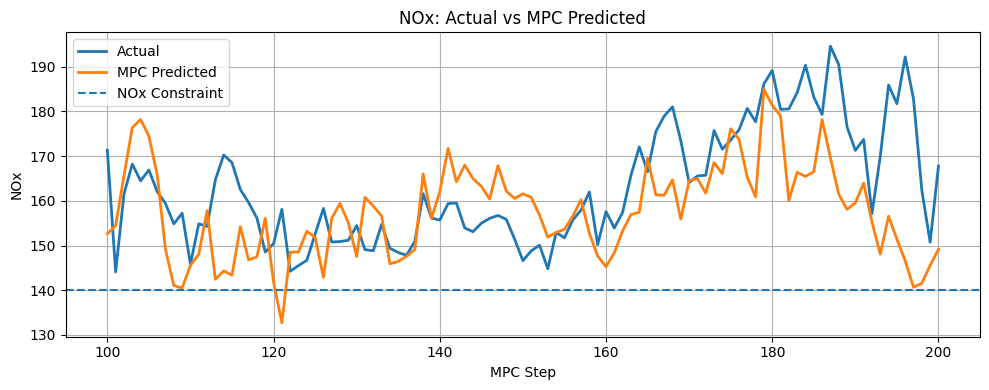

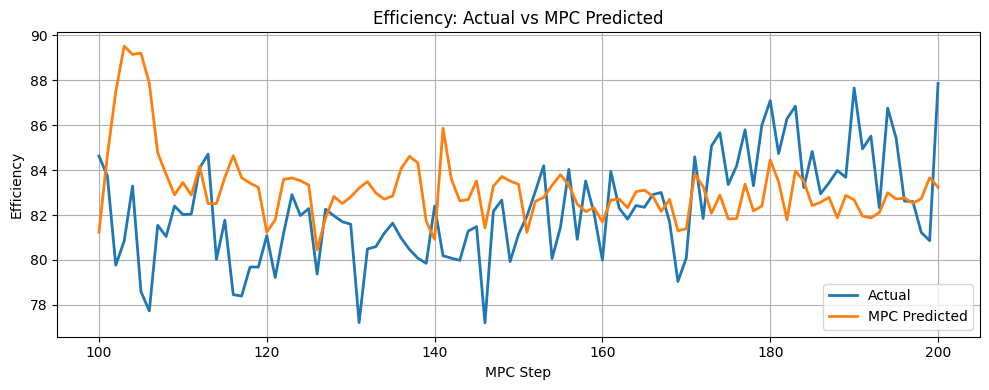

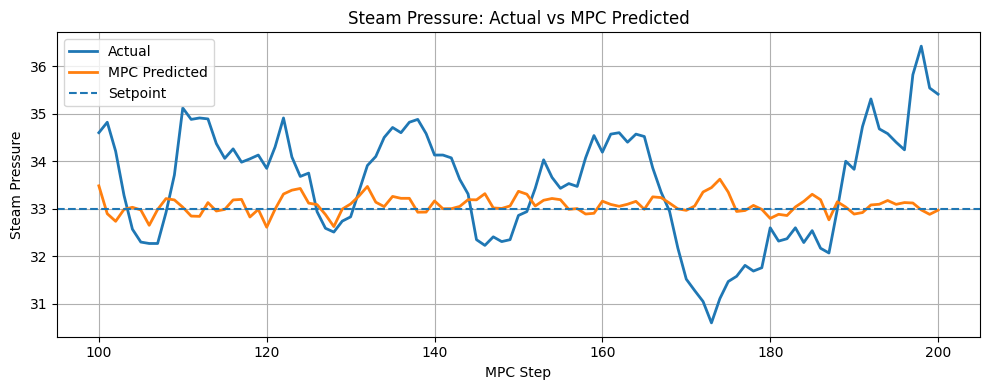

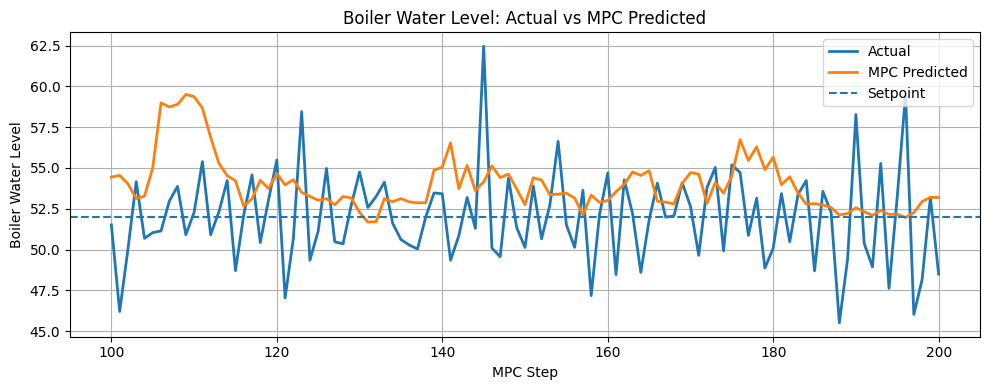

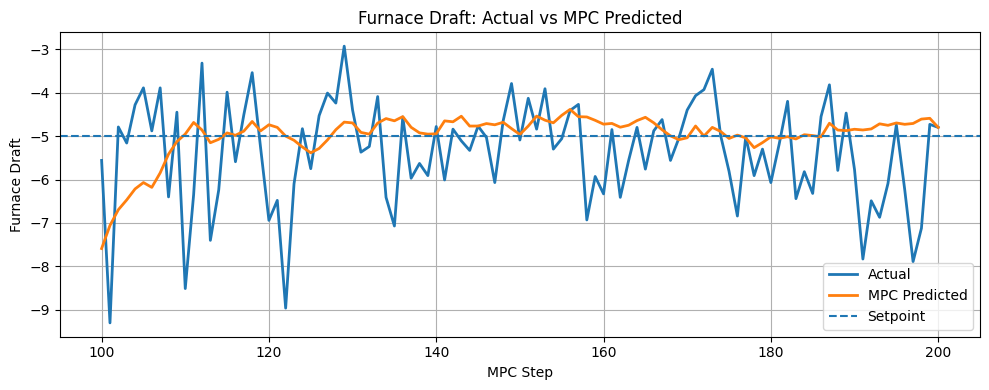

In [ ]:
# @title Boiler State Tracking Plots: Actual vs MPC

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load Excel file
# -----------------------------
results_df = pd.read_excel('/content/0.6,0.,6,1.1,1.3,1.3.xlsx')

# Check column names
print("Available columns:")
print(results_df.columns.tolist())

display(results_df.head())

# -----------------------------
# State mapping
# Format:
# (Plot title, Actual column, Predicted column, Reference value, Reference label)
# -----------------------------
state_map = [
    ("NOx", "Actual NOx", "Pred NOx", 140, "NOx Constraint"),
    ("Efficiency", "Actual Efficiency", "Pred Efficiency", None, None),
    ("Steam Pressure", "Actual Steam Pressure", "Pred Steam Pressure", 33, "Setpoint"),
    ("Boiler Water Level", "Actual Boiler Water Level", "Pred Boiler Water Level", 52, "Setpoint"),
    ("Furnace Draft", "Actual Furnace Draft", "Pred Furnace Draft", -5, "Setpoint"),
]

# -----------------------------
# Choose x-axis
# -----------------------------
if "step" in results_df.columns:
    x_axis = results_df["step"].values
else:
    x_axis = range(len(results_df))

# -----------------------------
# Plot Actual vs MPC Predicted
# -----------------------------
for name, actual_col, pred_col, ref_value, ref_label in state_map:

    plt.figure(figsize=(10, 4))

    plt.plot(x_axis, results_df[actual_col].values, label="Actual", linewidth=2)
    plt.plot(x_axis, results_df[pred_col].values, label="MPC Predicted", linewidth=2)

    if ref_value is not None:
        plt.axhline(ref_value, linestyle="--", label=ref_label)

    plt.title(f"{name}: Actual vs MPC Predicted")
    plt.xlabel("MPC Step")
    plt.ylabel(name)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Available columns:
['step', 'Pred NOx', 'Pred Efficiency', 'Pred Steam Pressure', 'Pred Boiler Water Level', 'Pred Furnace Draft', 'Actual NOx', 'Actual Efficiency', 'Actual Steam Pressure', 'Actual Boiler Water Level', 'Actual Furnace Draft', 'FuelRate', 'Water Flow', 'Fan Speed', 'O2 %', 'FuelRate_Actual', 'Water Flow_Actual', 'Fan Speed_Actual', 'O2 %_Actual', 'error']


,step,Pred NOx,Pred Efficiency,Pred Steam Pressure,Pred Boiler Water Level,Pred Furnace Draft,Actual NOx,Actual Efficiency,Actual Steam Pressure,Actual Boiler Water Level,Actual Furnace Draft,FuelRate,Water Flow,Fan Speed,O2 %,FuelRate_Actual,Water Flow_Actual,Fan Speed_Actual,O2 %_Actual,error
0,100,152.624344,81.238037,33.482918,54.438416,-7.588499,171.330323,84.628433,34.60,51.51,-5.56,0.018624,15609.336434,48.746604,6.453594,0.05,8443.68,64.73,8.19,NaN
1,101,154.464798,84.652840,32.896259,54.543655,-7.057311,144.087226,83.743128,34.82,46.21,-9.30,0.165295,12649.143945,48.419591,4.630253,0.06,13114.65,63.03,8.19,NaN
2,102,165.551315,87.493103,32.736671,54.027729,-6.695009,161.517399,79.763184,34.21,50.02,-4.79,0.230814,15014.837777,49.202338,4.826377,0.05,11867.01,62.59,9.66,NaN
3,103,176.360229,89.519211,32.987030,53.128517,-6.469090,168.234395,80.834199,33.28,54.16,-5.16,0.261512,15324.065549,48.476183,5.591294,0.05,10251.04,63.34,10.34,NaN
4,104,178.210159,89.153336,33.031116,53.271873,-6.216152,164.480123,83.288619,32.57,50.69,-4.28,0.207664,17258.336218,48.321788,5.928101,0.06,12444.79,63.19,9.14,NaN


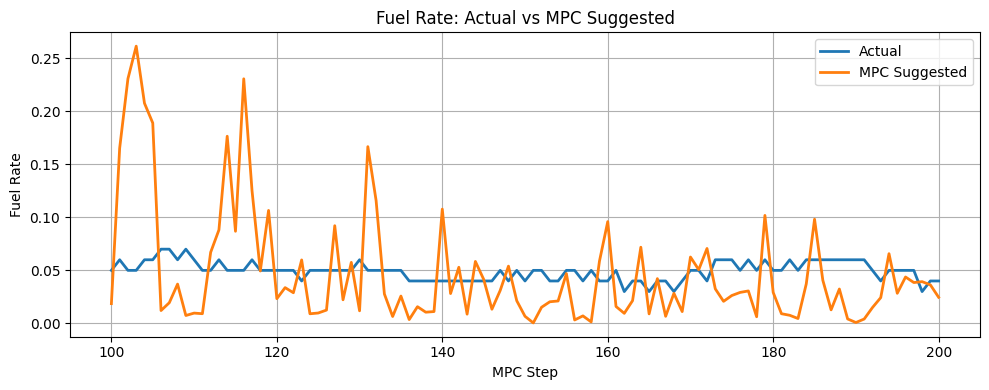

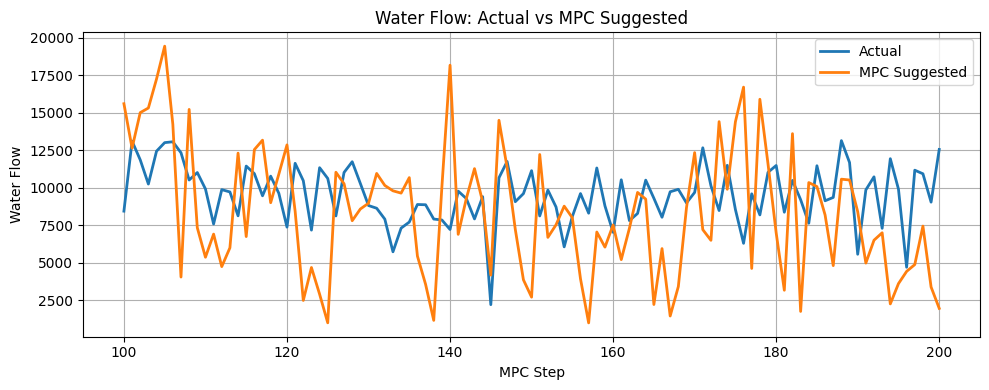

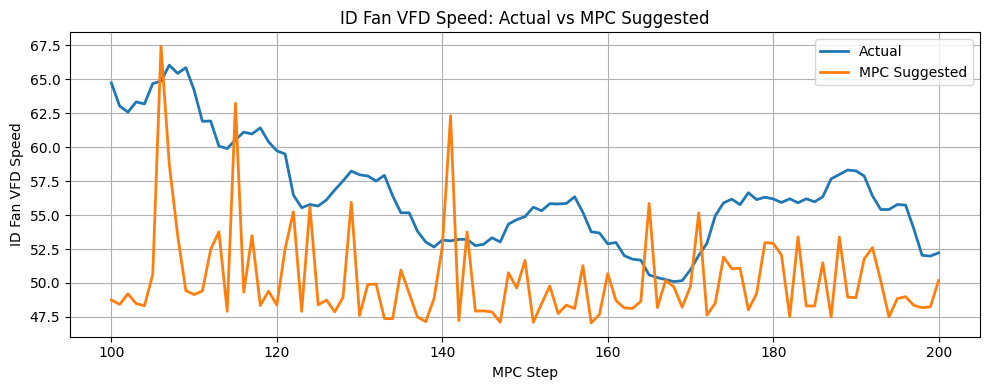

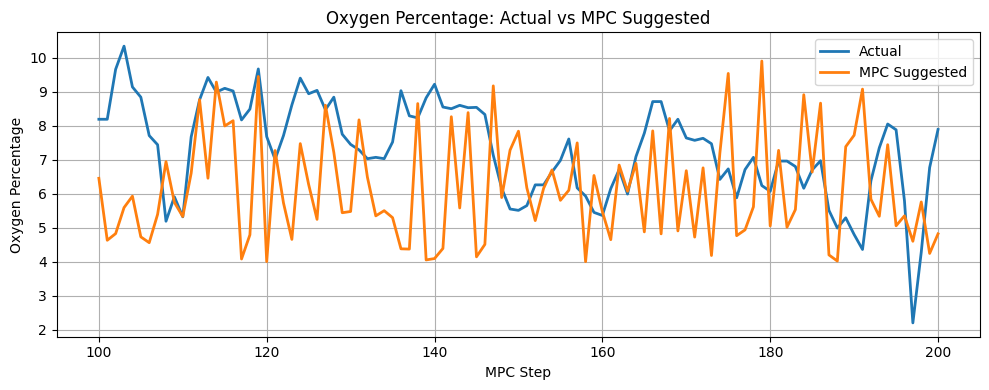

In [ ]:
# @title Boiler Control Plots: Actual vs MPC Suggested

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load Excel file
# -----------------------------
results_df = pd.read_excel('/content/0.6,0.,6,1.1,1.3,1.3.xlsx')

# Check column names
print("Available columns:")
print(results_df.columns.tolist())

display(results_df.head())

# -----------------------------
# Control mapping
# Format:
# (Plot title, Actual column, MPC suggested column)
# -----------------------------
control_map = [
    ("Fuel Rate", "FuelRate_Actual", "FuelRate"),
    ("Water Flow", "Water Flow_Actual", "Water Flow"),
    ("ID Fan VFD Speed", "Fan Speed_Actual", "Fan Speed"),
    ("Oxygen Percentage", "O2 %_Actual", "O2 %"),
]

# -----------------------------
# Choose x-axis
# -----------------------------
if "step" in results_df.columns:
    x_axis = results_df["step"].values
else:
    x_axis = range(len(results_df))

# -----------------------------
# Plot Actual vs MPC Suggested Controls
# -----------------------------
for name, actual_col, mpc_col in control_map:

    plt.figure(figsize=(10, 4))

    plt.plot(x_axis, results_df[actual_col].values, label="Actual", linewidth=2)
    plt.plot(x_axis, results_df[mpc_col].values, label="MPC Suggested", linewidth=2)

    plt.title(f"{name}: Actual vs MPC Suggested")
    plt.xlabel("MPC Step")
    plt.ylabel(name)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# @title Control Effort by Area Under Curve: Actual vs MPC

import numpy as np
import pandas as pd

# -----------------------------
# Control columns
# -----------------------------
control_map = [
    ("Fuel Rate", "FuelRate_Actual", "FuelRate"),
    ("Water Flow", "Water Flow_Actual", "Water Flow"),
    ("Fan Speed", "Fan Speed_Actual", "Fan Speed"),
    ("Oxygen Percentage", "O2 %_Actual", "O2 %"),
]

# -----------------------------
# Choose x-axis
# -----------------------------
if "step" in results_df.columns:
    x_axis = results_df["step"].values
else:
    x_axis = np.arange(len(results_df))

# -----------------------------
# Area under curve function
# -----------------------------
def area_under_curve(signal, x_axis):
    signal = pd.Series(signal).dropna().values
    x = np.array(x_axis[:len(signal)])

    # absolute area, safer for general signals
    return np.trapz(np.abs(signal), x)

# -----------------------------
# Calculate % change
# -----------------------------
summary = []

for name, actual_col, mpc_col in control_map:

    actual_area = area_under_curve(results_df[actual_col], x_axis)
    mpc_area = area_under_curve(results_df[mpc_col], x_axis)

    percent_change = ((mpc_area - actual_area) / actual_area) * 100 if actual_area != 0 else np.nan

    summary.append({
        "Control Input": name,
        "Actual Area": actual_area,
        "MPC Area": mpc_area,
        "% Change in Control Effort": percent_change
    })

control_effort_area_df = pd.DataFrame(summary)

control_effort_area_df

/tmp/ipykernel_3140/4174831896.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(np.abs(signal), x)


,Control Input,Actual Area,MPC Area,% Change in Control Effort
0,Fuel Rate,4.925,4.759773,-3.354857
1,Water Flow,951519.620,834593.365388,-12.288370
2,Fan Speed,5645.225,5029.082842,-10.914395
3,Oxygen Percentage,730.020,616.225698,-15.587833


In [ ]:
# @title Normalized Peak-to-Peak Fluctuation: Actual vs MPC

import numpy as np
import pandas as pd

control_map = [
    ("Fuel Rate", "FuelRate_Actual", "FuelRate"),
    ("Water Flow", "Water Flow_Actual", "Water Flow"),
    ("Fan Speed", "Fan Speed_Actual", "Fan Speed"),
    ("Oxygen Percentage", "O2 %_Actual", "O2 %"),
]

summary = []

def normalized_p2p(signal):
    signal = pd.Series(signal).dropna()

    p2p = signal.max() - signal.min()
    avg_level = np.abs(signal).mean()

    if avg_level < 1e-8:
        return np.nan

    return p2p / avg_level

for name, actual_col, mpc_col in control_map:

    actual_np2p = normalized_p2p(results_df[actual_col])
    mpc_np2p = normalized_p2p(results_df[mpc_col])

    percent_change = ((mpc_np2p - actual_np2p) / actual_np2p) * 100 if actual_np2p != 0 else np.nan

    summary.append({
        "Control Input": name,
        "Actual Normalized P2P": actual_np2p,
        "MPC Normalized P2P": mpc_np2p,
        "% Change in Normalized P2P": percent_change
    })

np2p_df = pd.DataFrame(summary)
np2p_df

,Control Input,Actual Normalized P2P,MPC Normalized P2P,% Change in Normalized P2P
0,Fuel Rate,0.812877,5.514437,578.384946
1,Water Flow,1.148736,2.210568,92.434878
2,Fan Speed,0.282439,0.405457,43.555392
3,Oxygen Percentage,1.113920,0.958494,-13.953096
